In [1]:
import cdms
import numpy as np
import os 
from ROOT import *
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts

import matplotlib.pyplot as plt
#plt.style.use("../sample_scripts/scdms.mplstyle")
plt.style.use("grayscale")

Welcome to JupyROOT 6.28/10


In [ ]:
## Identify series list and pull data from data catalog

series_list=['23231216_013604', '23231216_043946', '23231216_100125', '23231216_145300', '23231216_182937', '23231216_194929', '23231216_211119', '23231216_233807', 
        '23231217_135018', '23231217_171613', '23231217_212512', '23231218_093255', '23231218_152721', '23231218_190035', '23231218_223530', '23231219_034952', '23231219_110331', 
        '23231219_184002', '23231216_115012', '23231220_012745'] # Ge calibration  

dc = CDMSDataCatalog().findData(
    Facility    = "CUTE",
    nFridgeRun  = 37,
    Series      = series_list,
    ProdTag     = "CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2.",
    nMergeLevel = 1,
    dofetch     = True
)

filepath = [x.filePath for x in dc]
det = 1 # detector number
df = CDataFrame("rqDir/zip"+str(det), filepath, friends = [[x+":rqDir/eventTree" for x in filepath]])

In [21]:
## Apply some basic data quality filters and get the RQs you're interested in
logfile = '"cute_tower3testing.log"'
df = df.Define("LEDLogFile", logfile) 
df = df.CDefine("LEDOn", supercuts.ledOn_old, ["EventTime", "LEDLogFile"])
df = df.Filter("!LEDOn")
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(det), "PTOFamps>0"])

RQs = ["PTOFamps","PTOFchisqLF", "PTOFdelay", "PTINTall","EventNumber", 'PS1'+'OFamps','PAS1'+'OFamps', 'PBS1'+'OFamps', 'PCS1'+'OFamps', 'PDS1'+'OFamps', 'PES1'+'OFamps', 'PFS1'+'OFamps', 'PAS2'+'OFamps', 'PBS2'+'OFamps', 'PCS2'+'OFamps', 'PDS2'+'OFamps', 'PES2'+'OFamps', 'PFS2'+'OFamps']
df_rqs = df_filtered.AsNumpy(RQs)

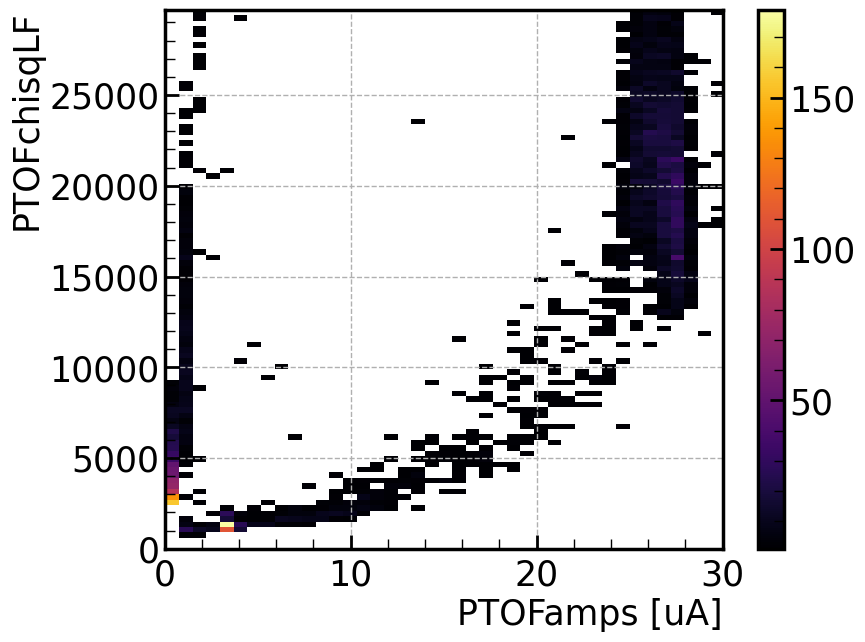

In [9]:
## Have a look at the PTOFamps vs chisq to make more cuts
plt.hist2d(df_rqs["PTOFamps"]*1E6,df_rqs["PTOFchisqLF"],bins=(200,np.arange(0,3E4,3E2)),cmin=1E-7,cmax=200,cmap="inferno")
plt.colorbar()
plt.ylabel("PTOFchisqLF")
plt.xlim(0,30)
plt.xlabel("PTOFamps [uA]")
plt.show()

In [22]:
## Now apply a more specific chisq cut - the 1 keV peak is (probably) the population at 3-4 uA
## Make a chisq cut to remove the higher eneryg stuff, and lets look closer at that region
df_filtered = df_filtered.Filters(["PTOFchisqLF<3000"])
df_rqs = df_filtered.AsNumpy(RQs)

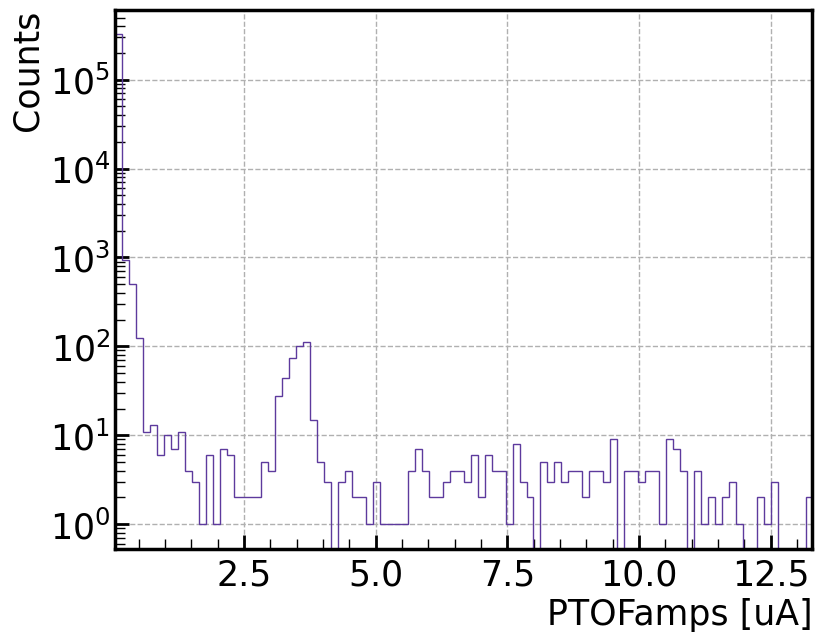

In [13]:
plt.hist(df_rqs["PTOFamps"]*1E6,bins=100, histtype='step')
plt.yscale("log")
plt.ylabel("Counts")
plt.xlabel("PTOFamps [uA]")
plt.show()

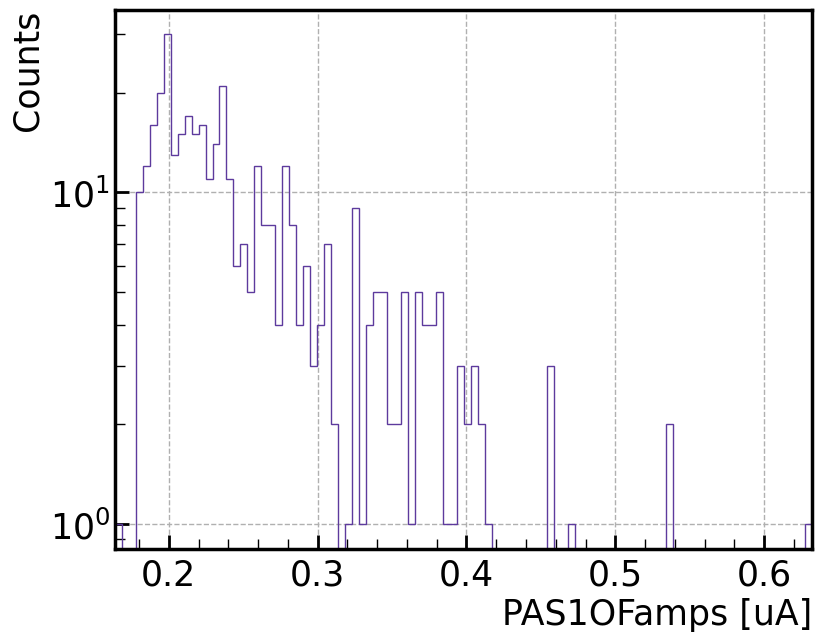

In [38]:
## Okay so lets define our 1keV events:
peak_events = df_filtered.Filters(["PTOFamps>2.5E-6","PTOFamps<4E-6"])
peak_rqs = peak_events.AsNumpy(RQs) 

## Now you can plot the various RQs from peak_rqs
plt.hist(peak_rqs["PAS1OFamps"]*1E6,bins=100, histtype='step')
plt.yscale("log")
plt.ylabel("Counts")
plt.xlabel("PAS1OFamps [uA]")
plt.show()

In [41]:
## Pulling raw data. This is pretty hacky - I'm sure theres a nicer way to get the raw data using datacat
series = series_list[0]
ev_num = [peak_rqs["EventNumber"][0]] # should pull out the event numbers you want from peak_rqs for a given series
run = '37'

raw_ds = CDMSDataCatalog().search('CDMS/CUTE/R'+run+'/Raw/'+series) ## datacat entry for series raw data
raw_filepath = CDMSDataCatalog().fetch(raw_ds)[0].filePath[:-28] ## this might break if the file names are different lengths.
reader = cdms.rawio.IO.RawDataReader(filepath=raw_filepath, series=[series]) ## io reader for raw data
raw_events = reader.read_events(detector_nums=det,event_nums = ev_num)

INFO: Found 37 midas raw data files
The file is: /fs/ddn/sdf/group/supercdms/data/CDMS/CUTE/R37/Raw/23231216_013604/23231216_013604_F0005.mid.gz

Opened raw midas file: /fs/ddn/sdf/group/supercdms/data/CDMS/CUTE/R37/Raw/23231216_013604/23231216_013604_F0005.mid.gz


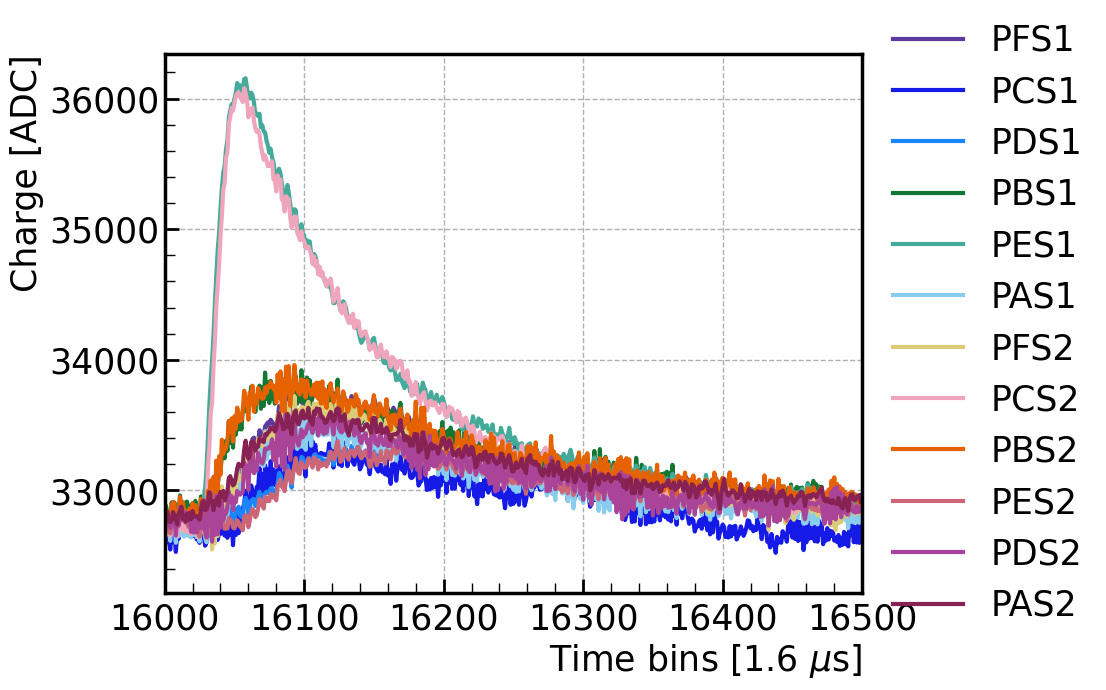

In [46]:
d = "Z1"
ser = 23231216013604 # this is just the series number without the hyphen
chan_list = ["PFS1","PCS1","PDS1","PBS1","PES1","PAS1","PFS2","PCS2","PBS2","PES2","PDS2","PAS2"]
for chan in chan_list:
    for event in list(raw_events[d][chan][ser].index):
        trace = raw_events[d][chan][ser][event]
        plt.plot(trace,label = chan)
plt.legend(loc = 'center left',bbox_to_anchor = [1,0.5])
plt.ylabel("Charge [ADC]")
plt.xlabel(r"Time bins [1.6 $\mu$s]")
plt.xlim(16000,16500)
plt.show()